# Explore SP accessibility vs. actual travel behavior

In [1]:
%load_ext autoreload
%autoreload 2
%cd D:\netmob25

D:\netmob25


In [2]:
import os
os.environ['USE_PYGEOS'] = '0'
import pandas as pd
import geopandas as gpd
import numpy as np
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import h3.api.numpy_int as h3
from shapely.geometry import Polygon
from shapely.geometry import Point


In [3]:
def weighted_median(data, weights):
    """
    Compute the weighted median of data with given weights.
    """
    data, weights = np.array(data), np.array(weights)
    sorter = np.argsort(data)
    data, weights = data[sorter], weights[sorter]
    cumsum = np.cumsum(weights) / np.sum(weights)
    return data[np.searchsorted(cumsum, 0.5)]

def bootstrap_median(data, weights=None, n_bootstrap=1000, random_state=None):
    """
    Calculate the (weighted) median and its bootstrap standard error.

    Parameters:
    - data: array-like, the dataset from which to sample
    - weights: array-like or None, weights for each data point (default None = unweighted)
    - n_bootstrap: int, number of bootstrap samples
    - random_state: int or None, for reproducibility

    Returns:
    - median_estimate: float, the weighted median of the original data
    - se_median: float, bootstrap standard error of the median
    """
    rng = np.random.default_rng(random_state)
    data = np.array(data)
    
    if weights is None:
        weights = np.ones_like(data, dtype=float)
    else:
        weights = np.array(weights, dtype=float)

    # Original weighted median
    median_estimate = weighted_median(data, weights)

    # Bootstrap
    medians = []
    probs = weights / weights.sum()
    for _ in range(n_bootstrap):
        sample_idx = rng.choice(len(data), size=len(data), replace=True, p=probs)
        medians.append(weighted_median(data[sample_idx], weights[sample_idx]))
    se_median = np.std(medians, ddof=1)

    return median_estimate, se_median

In [4]:
import matplotlib as mpl
def setup_mpl():
    mpl.rc('font', size = 9)
    mpl.rcParams['legend.fontsize'] = 'small'
    mpl.rcParams['legend.fontsize'] = 'small'
    mpl.rcParams['xtick.labelsize'] = 'small'
    mpl.rcParams['ytick.labelsize'] = 'small'
    mpl.rcParams['lines.linewidth'] = 1
    mpl.rcParams['xtick.major.width'] = 1
    mpl.rcParams['ytick.major.width'] = 1
    mpl.rcParams['xtick.minor.width'] = 1
    mpl.rcParams['ytick.minor.width'] = 1
    mpl.rcParams['xtick.major.size'] = 3
    mpl.rcParams['ytick.major.size'] = 3
    mpl.rcParams['xtick.minor.size'] = 1.5
    mpl.rcParams['ytick.minor.size'] = 1.5
    mpl.rcParams['axes.linewidth'] = 1
    mpl.rcParams['xtick.top'] = False
    mpl.rcParams['ytick.right'] = False
    mpl.rcParams['mathtext.default'] = 'regular'
    mpl.rcParams['xtick.major.pad'] = '2.3'
    mpl.rcParams['ytick.major.pad' ]= '2.3'
    mpl.rcParams['axes.labelpad'] = 2

setup_mpl()

## 1. Load data

In [5]:
df_p = pd.read_csv('dbs/data_p/commuter_attributes.csv')
df_a = pd.read_csv('dbs/data_p/commuter_sp_accessibility_r.csv')
df_a['mode'] = df_a['mode'].map({'car': 'Car', 'pt': 'Public transit'})
df_r = pd.read_csv('dbs/data_p/commuter_mobi_efficiency_daily.csv')
# Consider only weekdays for this stage (SPA alignment)
# df_r = df_r[~df_r.dow.isin(['saturday', 'sunday'])]
print(df_p.columns, '\n', df_a.columns, '\n', df_r.columns, '\n')

Index(['ID', 'time_threshold', 'amenity', 'mode', 'access_h', 'codgeo',
       'weight_ind', 'Gender', 'Age', 'Education', 'Household_type', 'Car_no',
       'Bike_no', 'Two_wheeler_no', 'Escooter_no', 'pt_sub', 'main_mode'],
      dtype='object') 
 Index(['ID', 'mode', 'ak'], dtype='object') 
 Index(['ID', 'date', 'trip_chaining_presence', 'freq_hws', 'xs_total_hws',
       'total_travel_time', 'activity_time_third', 'activity_time_work_study',
       'activity_time_home', 'entropy_naive', 'entropy_mm', 'gini_simpson',
       'hill_q1', 'n_visits', 'activity_nh_ratio', 'dow', 'day_type',
       'weight_day', 'main_mode_day'],
      dtype='object') 



C:\Users\yuanlia\AppData\Local\Temp\ipykernel_7640\3303172355.py:1: DtypeWarning: Columns (13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_p = pd.read_csv('dbs/data_p/commuter_attributes.csv')


In [6]:
df_p.groupby('Household_type')['ID'].nunique().reset_index()

,Household_type,ID
0,0,520
1,1,534
2,2,235
3,3,132
4,4,36
5,5,12
6,6,965
7,7,17


In [7]:
len(df_r.drop_duplicates(subset=['ID', 'date']))

14169

## 2. Individual groups
Car users vs. non-car users (main_mode); Females vs. Males (Gender).

In [8]:
df_p['main_mode'].unique()

array(['Active', 'Private car (driver)', 'Public transit', 'Micro',
       'Private car (passenger)', 'Other', 'Taxi'], dtype=object)

In [9]:
df_p.loc[:, 'main_mode_r'] = df_p['main_mode'].\
    apply(lambda x: 'Car' if x in ['Private car (driver)', 'Private car (passenger)'] else 'Public transit' if x=='Public transit' else 'Active/Micro' if x in ['Active', 'Micro'] else 'Other')

In [10]:
print(df_p.drop_duplicates(subset=['ID'])['Gender'].value_counts())
df_p.drop_duplicates(subset=['ID']).value_counts(['main_mode_r', 'Gender']).sort_index()

Gender
Woman    1347
Man      1104
Name: count, dtype: int64


main_mode_r     Gender
Active/Micro    Man       489
                Woman     485
Car             Man       366
                Woman     548
Other           Man         2
                Woman       1
Public transit  Man       247
                Woman     313
Name: count, dtype: int64

## 3. Efficiency: Travel time vs. activity time

In [ ]:
df_r2plot = df_r.groupby("ID").agg({
    "entropy_mm": "first",
    "hill_q1": "first",
    "activity_nh_ratio": lambda x: (x * df_r.loc[x.index, "weight_day"]).sum() / df_r.loc[x.index, "weight_day"].sum(),
    "activity_time_third": lambda x: (x * df_r.loc[x.index, "weight_day"]).sum() / df_r.loc[x.index, "weight_day"].sum(),
    "total_travel_time": lambda x: (x * df_r.loc[x.index, "weight_day"]).sum() / df_r.loc[x.index, "weight_day"].sum(),
    "xs_total_hws": lambda x: (x * df_r.loc[x.index, "weight_day"]).sum() / df_r.loc[x.index, "weight_day"].sum(),
    "trip_chaining_presence": lambda x: 1 if sum(x) > 0 else 0
}).reset_index()
df_r2plot = df_r2plot.fillna(0)
df_r2plot.head()

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df_r2plot["activity_time_third"], df_r2plot["xs_total_hws"], alpha=0.3)

plt.xlabel("Total travel time (minutes)")
plt.ylabel("Activity NH Ratio (log scale)")
plt.yscale("log")  # <-- log transform
plt.xscale("log")  # <-- log transform
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### 2.1 Efficiency vs. diversity

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df_r2plot["xs_total_hws"], df_r2plot["hill_q1"], alpha=0.3)

plt.xlabel("Third place entropy (entropy_mm)")
plt.ylabel("Activity NH Ratio (log scale)")
plt.yscale("log")  # <-- log transform
plt.xscale("log")  # <-- log transform
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### 2.2 Group differences

In [12]:
df_r2plot = df_r2plot.merge(df_p.drop_duplicates(subset=['ID'])[['Gender', 'main_mode_r', 'ID', 'Age', 'Education', 'Household_type', 'weight_ind']], on='ID', how='left')

In [ ]:
# Make sure your Gender column is categorical for coloring
df_r2plot["main_mode_r"] = df_r2plot["main_mode_r"].astype("category")

# Jointplot with scatter and KDE marginals
g = sns.jointplot(
    data=df_r2plot[(df_r2plot["main_mode_r"] != "Other") & (df_r2plot["entropy_mm"] > 0.01)],
    y="hill_q1",
    x="xs_total_hws",
    hue="Gender",
    kind="scatter",
    marginal_kws=dict(common_norm=False, fill=True, alpha=0.3),
    palette="Set1",
    height=8,
    alpha=0.3
)

# Set log-log axes
g.ax_joint.set_xscale("log")
g.ax_joint.set_yscale("log")

# Axis labels
g.set_axis_labels("Third place entropy (entropy_mm)", "Activity NH Ratio (log scale)")

plt.tight_layout()
plt.show()

## 4. Space-time accessibility

In [14]:
df_r2plot = df_r2plot.merge(df_p.loc[(df_p['time_threshold'] == '30 min') & (df_p['amenity'] == 'Social & Leisure'), 
                                     ['ID', 'access_h', 'mode']], on='ID', how='left')

In [15]:
# Step 1: get IDs where main_mode_r is "Car"
car_ids = df_r2plot.loc[df_r2plot["main_mode_r"] == "Car", "ID"].unique()

# Step 2: filter
df_filtered = df_r2plot[
    ((df_r2plot["ID"].isin(car_ids)) & (df_r2plot["main_mode_r"] == df_r2plot["mode"])) |
    ((~df_r2plot["ID"].isin(car_ids)) & (df_r2plot["mode"] != "Car"))
]

In [16]:
df_filtered = df_filtered.merge(df_a, on=['ID', 'mode'], how='left')

In [ ]:
# Make sure your Gender column is categorical for coloring
# df_filtered["situation"] = df_filtered["situation"].astype("category")

# Jointplot with scatter and KDE marginals
g = sns.jointplot(
    data=df_filtered,
    x="ak",
    y="access_h",
    hue="main_mode_r",
    kind="scatter",
    marginal_kws=dict(common_norm=False, fill=True, alpha=0.3),
    palette="Set1",
    height=8,
    alpha=0.3
)

# Set log-log axes
g.ax_joint.set_xscale("log")
g.ax_joint.set_yscale("log")

# Axis labels
g.set_axis_labels("Space-time accessibility to leisure", "Home-based accessibility to social & leisure")

plt.tight_layout()
plt.show()

In [ ]:
df_filtered.iloc[0]

In [19]:
df_filtered.loc[:, 'ak_cat'] = df_filtered['ak'].apply(lambda x: 'Zero' if x == 0 else 'Non-zero')
df_filtered = df_filtered[df_filtered['main_mode_r'] != 'Other'].copy()

In [ ]:
df_filtered["main_mode_r"] = df_filtered["main_mode_r"].astype("category")
df_filtered.groupby(['ak_cat', 'main_mode_r']).agg({
    'ID': 'count',  # Count of IDs
    'entropy_mm': 'mean',  # Mean of entropy_mm
    'hill_q1': 'mean',  # Mean of hill_q1
    'activity_time_third': 'mean',  # Mean
    'access_h': 'mean',  # Mean of access_h
    'xs_total_hws': 'mean',
    'ak': 'mean',  # Mean of ak
    'trip_chaining_presence': 'sum'
}).reset_index().sort_values(by=['ak_cat', 'main_mode_r'])

In [21]:
df_filtered.loc[:, 'ak_log'] = df_filtered['ak'].apply(lambda x: np.log(x) if x > 0 else 0)

In [22]:
df_filtered.columns

Index(['ID', 'entropy_mm', 'hill_q1', 'activity_nh_ratio',
       'activity_time_third', 'total_travel_time', 'xs_total_hws',
       'trip_chaining_presence', 'Gender', 'main_mode_r', 'Age', 'Education',
       'Household_type', 'weight_ind', 'access_h', 'mode', 'ak', 'ak_cat',
       'ak_log'],
      dtype='object')

In [ ]:
# ----- Effect on diversity -----
model_entropy = smf.ols(
    formula="hill_q1 ~ ak_log + C(Gender) + C(mode) + Age + C(Education) + C(Household_type)",
    data=df_filtered
).fit(weights=df_filtered["weight_ind"])

print("\n--- Entropy_mm model (weighted) ---")
print(model_entropy.summary())

## 5 Prepare data for visualization (Figure 2)

In [23]:
df_filtered.columns

Index(['ID', 'entropy_mm', 'hill_q1', 'activity_nh_ratio',
       'activity_time_third', 'total_travel_time', 'xs_total_hws',
       'trip_chaining_presence', 'Gender', 'main_mode_r', 'Age', 'Education',
       'Household_type', 'weight_ind', 'access_h', 'mode', 'ak', 'ak_cat',
       'ak_log'],
      dtype='object')

In [24]:
df_filtered = df_filtered.merge(df_p[['ID', 'codgeo', 'pt_sub']].drop_duplicates(subset=['ID']), on='ID', how='left')

In [38]:
# Statistical test
from scipy.stats import rankdata

# ---- Weighted Pearson correlation ---- #
def weighted_pearson(x, y, w):
    w = np.array(w)
    x = np.array(x)
    y = np.array(y)

    mean_x = np.average(x, weights=w)
    mean_y = np.average(y, weights=w)

    cov_xy = np.average((x - mean_x) * (y - mean_y), weights=w)
    std_x = np.sqrt(np.average((x - mean_x)**2, weights=w))
    std_y = np.sqrt(np.average((y - mean_y)**2, weights=w))

    return cov_xy / (std_x * std_y)

# ---- Weighted Spearman correlation ---- #
def weighted_spearman(x, y, w):
    rx = rankdata(x, method='average')
    ry = rankdata(y, method='average')
    return weighted_pearson(rx, ry, w)

# ---- Permutation test for significance ---- #
def weighted_spearman_pval(x, y, w, n_perm=5000, seed=42):
    np.random.seed(seed)

    observed = weighted_spearman(x, y, w)
    perm_corrs = []

    for _ in range(n_perm):
        y_perm = np.random.permutation(y)
        perm_corrs.append(weighted_spearman(x, y_perm, w))

    perm_corrs = np.array(perm_corrs)

    # Two-sided p-value
    p_value = np.mean(np.abs(perm_corrs) >= np.abs(observed))
    
    return observed, p_value

# ---- Run test by mode ---- #
def run_by_mode(df):
    modes = df['mode'].unique()

    for m in modes:
        sub = df[(df['mode'] == m) & (df['ak_log'] > 0)].copy()

        if len(sub) < 10:
            print(f"Mode {m}: Too few observations ({len(sub)}). Skipping.\n")
            continue

        print(f"=== Mode: {m} (n={len(sub)}) ===")

        # Test 1: hill_q1 ~ ak_log
        r1, p1 = weighted_spearman_pval(
            sub['hill_q1'].values,
            sub['ak_log'].values,
            sub['weight_ind'].values
        )
        print(f"hill_q1 ~ ak_log: r = {r1:.4f}, p = {p1:.4f}")

        # Test 2: total_travel_time ~ ak_log
        r2, p2 = weighted_spearman_pval(
            sub['total_travel_time'].values,
            sub['ak_log'].values,
            sub['weight_ind'].values
        )
        print(f"total_travel_time ~ ak_log: r = {r2:.4f}, p = {p2:.4f}\n")


# ---- Example usage ---- #
run_by_mode(df_filtered)

=== Mode: Public transit (n=490) ===
hill_q1 ~ ak_log: r = 0.1252, p = 0.0458
total_travel_time ~ ak_log: r = -0.1309, p = 0.0392

=== Mode: Car (n=424) ===
hill_q1 ~ ak_log: r = -0.0523, p = 0.4630
total_travel_time ~ ak_log: r = -0.1792, p = 0.0116



In [25]:
# access_col: the column to bin
# step: 0.5 → boundaries at 10^0, 10^0.5, 10^1, ...
def assign_log_bins(df, access_col, step=0.5):
    s = df[access_col].astype(float)

    # Ignore non-positive values for log binning (they'll become NaN groups)
    pos = s[s > 0]
    if pos.empty:
        df['grp_cell'] = np.nan
        return df

    # Build log10-spaced edges covering the data
    lo = np.floor(np.log10(pos.min()) / step) * step
    hi = np.ceil(np.log10(pos.max()) / step) * step
    edges = 10 ** np.arange(lo, hi + step, step)

    # Cut using those edges; label groups 1..K
    labels = range(1, len(edges))
    df['grp_cell'] = pd.cut(s, bins=edges, labels=labels, include_lowest=True)

    # Optional: make it float like your original
    df['grp_cell'] = df['grp_cell'].astype(float)
    return df


def assign_quantile_bins(data, access_col='access_h', num_grp=None):
    data = data.copy()
    data.loc[:, 'grp_cell'] = pd.qcut(data.loc[:, access_col], q=num_grp, labels=[i for i in range(1, num_grp + 1)])
    data.loc[:, 'grp_cell'] = data.loc[:, 'grp_cell'].astype(float)
    return data

In [26]:
def access_vs_y(df=None, num_grp=None, access_col='access_h', step=0.4):
    df = pd.concat([assign_quantile_bins(df_filtered[(df_filtered[access_col] > 0) & (df_filtered['mode'] == 'Car')], access_col=access_col, num_grp=num_grp),
                   assign_quantile_bins(df_filtered[(df_filtered[access_col] > 0) & (df_filtered['mode'] == 'Public transit')], access_col=access_col, num_grp=num_grp)])
    #df = pd.concat([assign_log_bins(df_filtered[(df_filtered[access_col] > 0) & (df_filtered['mode'] == 'Car')], access_col=access_col, step=step),
    #                assign_log_bins(df_filtered[(df_filtered[access_col] > 0) & (df_filtered['mode'] == 'Public transit')], access_col=access_col, step=step)])
    def grp_stats(data):
        md_e, md_err_e = bootstrap_median(data["hill_q1"], weights=data['weight_ind'], n_bootstrap=1000)
        md_t, md_err_t = bootstrap_median(data["xs_total_hws"], weights=data['weight_ind'], n_bootstrap=1000)
        md_a, md_err_a = bootstrap_median(data["activity_time_third"], weights=data['weight_ind'], n_bootstrap=1000)
        share = data.loc[data['trip_chaining_presence'] == 1, 'weight_ind'].sum() / data['weight_ind'].sum()
        md_tt, md_err_tt = bootstrap_median(data["total_travel_time"], weights=data['weight_ind'], n_bootstrap=1000)
        return pd.Series(dict(r=data[access_col].median(),
                              hill_q1_50=md_e,
                              hill_q1_err=md_err_e,
                              total_travel_time_50=md_tt,
                              total_travel_time_err=md_err_tt,
                              activity_time_third_50=md_a,
                              activity_time_third_err=md_err_a,
                              xs_total_hws_50=md_t,
                              xs_total_hws_err=md_err_t,
                              trip_chaining_presence_50=share,
                              trip_chaining_presence_err=0))
    df_g = df.groupby(['grp_cell', 'mode'], observed=True).apply(grp_stats, include_groups=False).reset_index()
    return df_g

In [ ]:
df_ak_g = access_vs_y(df=df_filtered[df_filtered['ak'] > 0].copy(), num_grp=15, access_col='ak')
df_ak_g.loc[:, 'a_type'] = 'Space-time accessibility to leisure'
df_ah_g = access_vs_y(df=df_filtered[df_filtered['access_h'] > 0].copy(), num_grp=15, access_col='access_h')
df_ah_g.loc[:, 'a_type'] = 'Home-based accessibility to social & leisure'
df_ag = pd.concat([df_ak_g, df_ah_g], ignore_index=True)
df_ag.head()

In [28]:
def access_impact_plot(df_b=None, y='diversity', ylb=None):
    fig, axes = plt.subplots(1, 2, figsize=(4, 2), dpi=300, sharey=True)

    # --- Helper to plot errorbars + fit line for a subset ---
    def plot_with_fit(ax, df_sub, title, color):
        x = df_sub["r"].to_numpy(dtype=float)
        y50 = df_sub[f"{y}_50"].to_numpy(dtype=float)
        yerr = df_sub[f"{y}_err"].to_numpy(dtype=float)

        # Error bars
        ax.errorbar(
            x, y50,
            yerr=[yerr, yerr],
            fmt='o',
            capsize=2,
            color=color,
            markersize=4
        )

        # ----- Fit y ~ a*log10(x) + b -----
        mask = np.isfinite(x) & (x > 0) & np.isfinite(y50)
        if mask.sum() >= 2:
            x_fit = x[mask]
            y_fit = y50[mask]
            logx = np.log10(x_fit)
            m, b = np.polyfit(logx, y_fit, deg=1)

            xs = np.geomspace(x_fit.min(), x_fit.max(), 200)
            ys = m * np.log10(xs) + b
            ax.plot(xs, ys, color=color, lw=0.7, alpha=0.7)

        ax.set_xscale("log")
        ax.set_xlabel("$A_i$")
        ax.set_title(title, fontsize=10, loc="left")
        sns.despine(ax=ax)

    # --- Car (left plot) ---
    data1 = df_b[df_b['mode'] == 'Car'].copy()
    plot_with_fit(axes[0], data1, title="Car", color="#0fbcf9")

    # --- Public transit (right plot) ---
    data2 = df_b[df_b['mode'] == 'Public transit'].copy()
    plot_with_fit(axes[1], data2, title="Public transit", color="#05c46b")

    # Shared y-axis label
    axes[0].set_ylabel(ylb)

    plt.tight_layout()
    return fig, axes

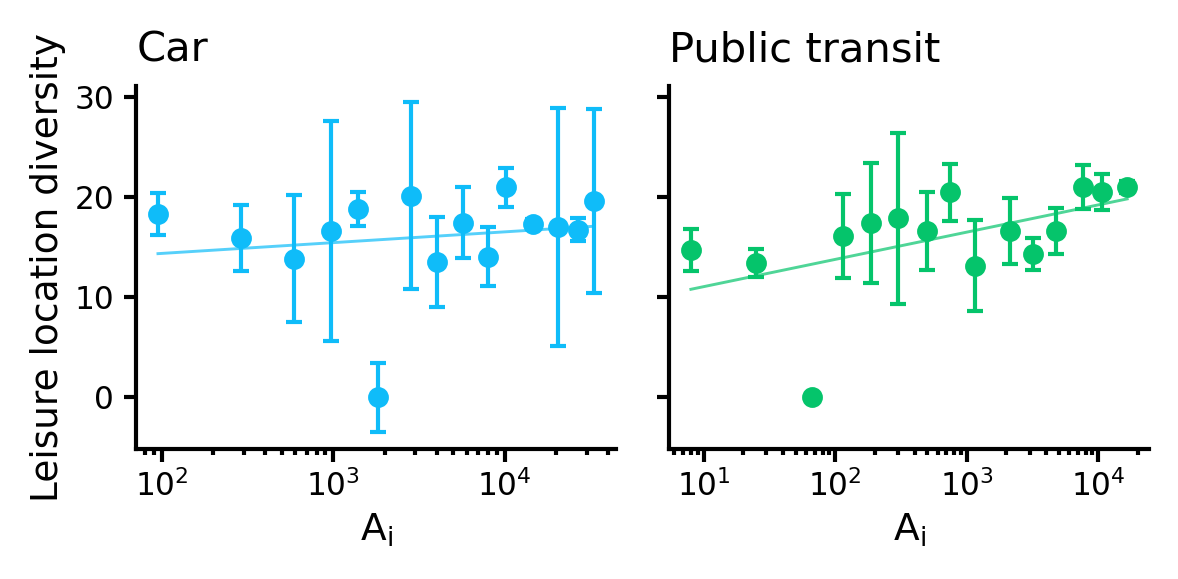

In [29]:
fig, _ = access_impact_plot(df_b=df_ag[df_ag['a_type'] == 'Space-time accessibility to leisure'], y='hill_q1', ylb="Leisure location diversity")
fig.savefig("figures/hill_q1.png", dpi=300, bbox_inches='tight')

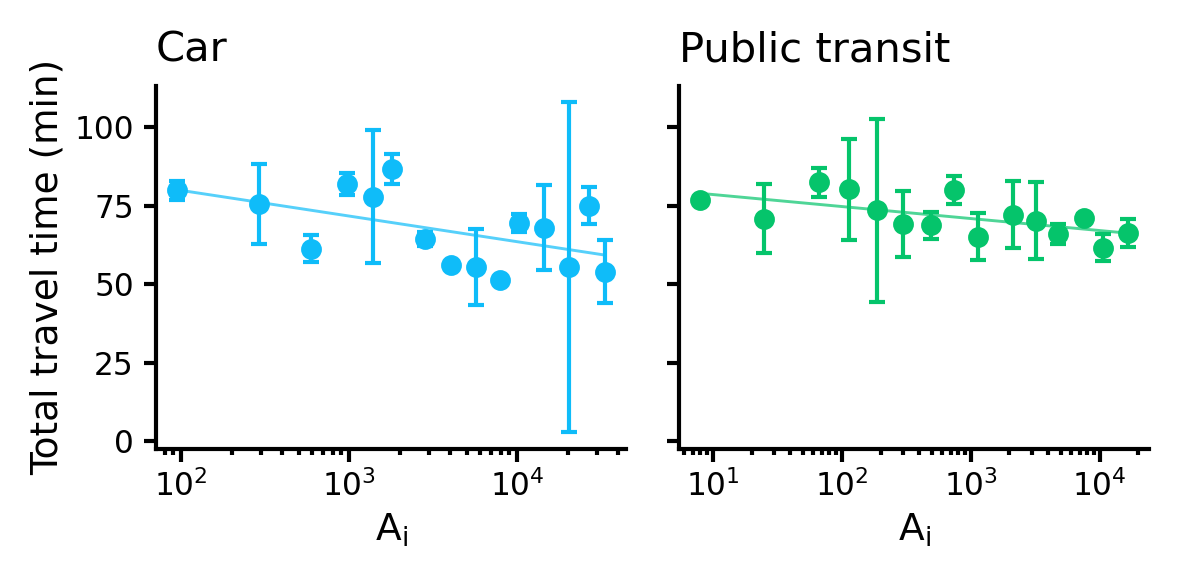

In [34]:
fig, _ = access_impact_plot(df_b=df_ag[df_ag['a_type'] == 'Space-time accessibility to leisure'], y='total_travel_time', ylb="Total travel time (min)")
fig.savefig("figures/total_travel_time.png", dpi=300, bbox_inches='tight')

In [ ]:
# fig, _ = access_impact_plot(df_b=df_ag[df_ag['a_type'] == 'Space-time accessibility to leisure'], y='xs_total_hws', ylb="Trip chaining complexity")
# fig.savefig("figures/xs_total_hws.png", dpi=300, bbox_inches='tight')

# fig, _ = access_impact_plot(df_b=df_ag[df_ag['a_type'] == 'Space-time accessibility to leisure'], y='trip_chaining_presence', ylb="Trip chaining share")
# fig.savefig("figures/trip_chaining_presence.png", dpi=300, bbox_inches='tight')

### 5.1 STA zero vs. non zero

In [30]:
def ak_cat_agg(data=None):
    trip_chaining_presence = data.loc[data['trip_chaining_presence'] == 1, 'weight_ind'].sum() / data['weight_ind'].sum() * 100
    md_e, md_err_e = bootstrap_median(data["hill_q1"], weights=data['weight_ind'], n_bootstrap=1000)
    md_t, md_err_t = bootstrap_median(data["xs_total_hws"], weights=data['weight_ind'], n_bootstrap=1000)
    md_a, md_err_a = bootstrap_median(data["activity_time_third"], weights=data['weight_ind'], n_bootstrap=1000)
    md_tt, md_err_tt = bootstrap_median(data["total_travel_time"], weights=data['weight_ind'], n_bootstrap=1000)
    return pd.Series(dict(hill_q1_50=md_e,
                          hill_q1_err=md_err_e,
                          total_travel_time_50=md_tt,
                          total_travel_time_err=md_err_tt,
                          activity_time_third_50=md_a,
                          activity_time_third_err=md_err_a,
                          xs_total_hws_50=md_t,
                          xs_total_hws_err=md_err_t,
                          trip_chaining_presence_50=trip_chaining_presence,
                          trip_chaining_presence_err=0))

df_chain_presence = df_filtered.groupby(['ak_cat', 'mode']).apply(ak_cat_agg, include_groups=False).reset_index()
df_chain_presence.head()

,ak_cat,mode,hill_q1_50,hill_q1_err,total_travel_time_50,total_travel_time_err,activity_time_third_50,activity_time_third_err,xs_total_hws_50,xs_total_hws_err,trip_chaining_presence_50,trip_chaining_presence_err
0,Non-zero,Car,17.034149,0.682800,69.502627,4.321915,13.766176,2.432675,0.282572,0.033289,72.517107,0.0
1,Non-zero,Public transit,17.121216,0.784030,72.745728,0.710405,25.583142,2.034912,0.265069,0.015885,72.095803,0.0
2,Zero,Car,16.970563,1.690243,103.351963,1.894660,10.571429,2.832987,0.308759,0.032685,72.611341,0.0
3,Zero,Public transit,15.257037,1.093614,100.068142,2.385290,13.327924,0.635725,0.166235,0.004941,63.974168,0.0


In [ ]:
# Map to SPA groups
df_chain_presence["SPA"] = df_chain_presence["ak_cat"].map({"Zero": "SPA = 0"}).fillna("SPA ≠ 0")

# 2×2 pivot
heat = (
    df_chain_presence.pivot(index="SPA", columns="mode", values="trip_chaining_presence_50")
      .reindex(index=["SPA = 0", "SPA ≠ 0"], columns=["Car", "Public transit"])
)

# Plot grouped bar chart
fig, ax = plt.subplots(1, 1, figsize=(2, 2), dpi=300, sharey=True)
ax = sns.barplot(
    data=df_chain_presence,
    x="mode",
    y="trip_chaining_presence_50",
    hue="SPA",
    palette={"SPA = 0": "gray", "SPA ≠ 0": "green"}
)

# Labels and title
ax.set_ylabel("w/ trip chaining (%)")
ax.set_xlabel("")
# ax.set_title("Trip-chaining presence by SPA and mode", loc="left", fontsize=10)
ax.legend(
    title="",
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=2
)
sns.despine()

plt.tight_layout()
fig.savefig("figures/trip_chaining_presence_spa.png", dpi=300, bbox_inches='tight')
plt.show()

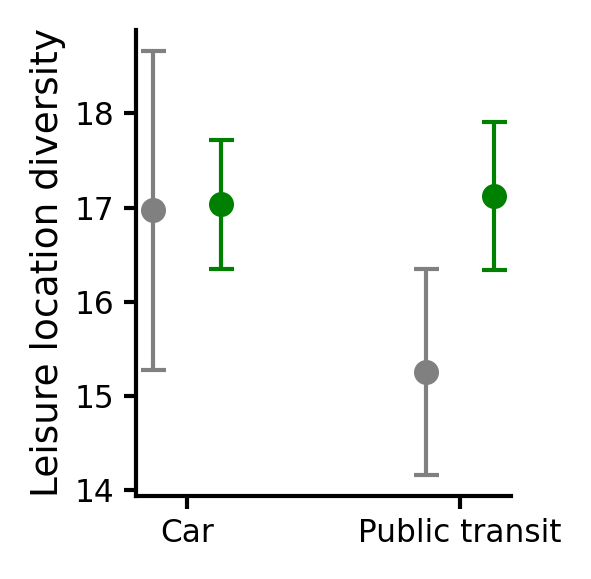

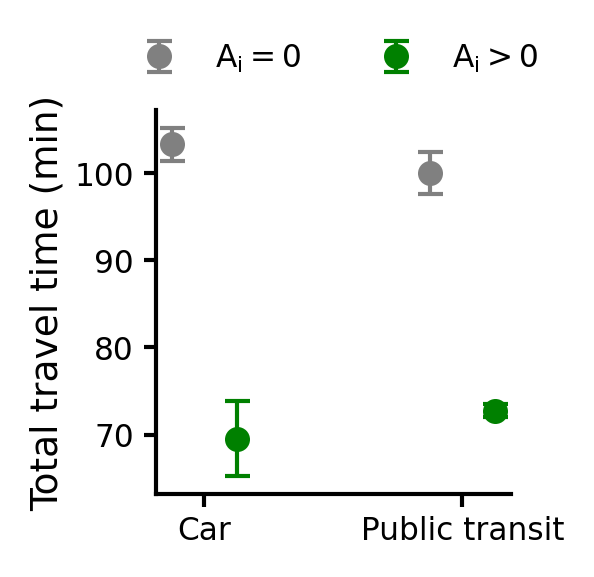

In [31]:
def entropy_errplot_combined(df, ylabel="Diversity (median ± SE)", var='hill_q1', showlegend=True):
    # expected columns: ak_cat ∈ {'Zero','Non-zero'}, mode ∈ {'Car','Public transit'},
    #                   entropy_mm_50, entropy_mm_err
    mode_order = ['Car', 'Public transit']
    spa_order  = ['Zero', 'Non-zero']
    colors = {'Zero': 'gray', 'Non-zero': 'green'}
    label_map = {'SPA=Zero': '$A_i=0$', 'SPA=Non-zero': '$A_i>0$'}
    fig, ax = plt.subplots(figsize=(2, 2), dpi=300)

    # Positioning: offset SPA within each mode
    width = 0.25
    x = np.arange(len(mode_order))  # positions for Car/PT

    for j, spa in enumerate(spa_order):
        sub = df[df['ak_cat'] == spa].copy()
        means = [sub.loc[sub['mode'] == m, f'{var}_50'].values[0] for m in mode_order]
        errs  = [sub.loc[sub['mode'] == m, f'{var}_err'].values[0] for m in mode_order]

        ax.errorbar(
            x + (j-0.5)*width, means,
            yerr=errs,
            fmt='o', ms=5, capsize=3,
            color=colors[spa],
            label=label_map[f"SPA={spa}"]
        )

    ax.set_xticks(x)
    ax.set_xticklabels(mode_order)
    ax.set_ylabel(ylabel)
    sns.despine(ax=ax)

    # Legend horizontal on top
    handles, labels = ax.get_legend_handles_labels()
    if showlegend:
        ax.legend(handles, labels, title="", frameon=False,
                loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2)

    plt.tight_layout()
    return fig, ax

# Usage
fig, _ = entropy_errplot_combined(df_chain_presence, ylabel="Leisure location diversity", var='hill_q1', showlegend=False)
fig.savefig("figures/hill_q1_spa.png", dpi=300, bbox_inches='tight')
plt.show()
fig, _ = entropy_errplot_combined(df_chain_presence, ylabel="Total travel time (min)", var='total_travel_time', showlegend=True)
fig.savefig("figures/total_travel_time_spa.png", dpi=300, bbox_inches='tight')
plt.show()
# fig, _ = entropy_errplot_combined(df_chain_presence, ylabel="Leisure activity time (min)", var='activity_time_third')
# fig.savefig("figures/activity_time_third_spa.png", dpi=300, bbox_inches='tight')
# plt.show()

In [32]:
df_filtered.loc[:, 'active_mode'] = df_filtered.loc[:, 'main_mode_r'].apply(lambda x: 1 if x == "Active/Micro" else 0)

In [33]:
df_filtered.dropna(inplace=True)
print(len(df_filtered))

2444


### 5.2 Heatmap

In [ ]:
# --- 2. Variables to plot ---
y_vars = ['hill_q1', 'activity_time_third', 'xs_total_hws']
df2plot = df_filtered.copy()
# --- 3. Loop over y variables ---
for y in y_vars:
    plt.figure(figsize=(5,4), dpi=300)
    
    # Create 2D heatmap using hexbin (better for continuous data) or hist2d
    hb = plt.hexbin(
        df2plot['ak_log'], df2plot[y],
        gridsize=25, cmap="viridis", bins='log'
    )
    
    plt.colorbar(hb, label="Counts (log scale)")
    plt.xlabel("ak_log")
    plt.ylabel(y)
    plt.title(f"2D heatmap: ak_log vs {y}")
    
    # Save
    fname = f"figures/heatmap_{y}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved {fname}")

Saved figures/heatmap_hill_q1.png
Saved figures/heatmap_activity_time_third.png
Saved figures/heatmap_xs_total_hws.png


## 6. Spatial distributions

In [ ]:
df_work = pd.read_csv('dbs/data_p/commuter_trips.csv')
df_work = df_work[df_work['purpose_d'] == 'HOME'].copy()
df_work.drop_duplicates(subset=['ID'], inplace=True)
df_work = df_work[['ID', 'end_lon', 'end_lat']].rename(columns={'ID': 'id', 'end_lon': 'lon', 'end_lat': 'lat'})
# Concatenate and drop duplicates
unique_coords = df_work[['lon', 'lat']].drop_duplicates()

# Reset index for clarity
unique_coords = unique_coords.reset_index(drop=True)

# Get corresponding h3 id (10) for each coordinate pair
tqdm.pandas(desc="Calculating H3 IDs")
unique_coords['h3_id'] = unique_coords.progress_apply(lambda row: h3.latlng_to_cell(row['lat'], row['lon'], res=7), axis=1)
# Extract unique h3_ids
h3_list = unique_coords['h3_id'].unique().tolist()
polygons = [Polygon(h3.cells_to_geo([x])['coordinates'][0]) for x in h3_list]

# Create a GeoDataFrame from unique h3_ids
gdf_h3 = gpd.GeoDataFrame(
    h3_list,
    geometry=polygons,
    crs="EPSG:4326"
)
gdf_h3.columns= ['h3_id', 'geometry']
gdf_h3.plot()

In [44]:
df_work = df_work.merge(unique_coords, on=['lon', 'lat'], how='left')
df_filtered = df_filtered.merge(df_work[['id', 'h3_id']], left_on='ID', right_on='id', how='left')

In [45]:
def area_agg(data):
    num = data['ID'].nunique()
    num_eq = data['weight_ind'].sum()
    ak_non_zero = data[data['ak_log'] > 0]['weight_ind'].sum() / data['weight_ind'].sum() * 100 # percent of non-zero ak
    activity_time_third, _ = bootstrap_median(data['activity_time_third'], data['weight_ind'])
    hill_q1, _ = bootstrap_median(data['hill_q1'], data['weight_ind'])
    tc_non_zero = data[data['trip_chaining_presence'] > 0]['weight_ind'].sum() / data['weight_ind'].sum() * 100 # percent of non-zero ak
    total_travel_time, _ = bootstrap_median(data['total_travel_time'], data['weight_ind'])
    return pd.Series(dict(num=num, num_eq=num_eq, ak_non_zero=ak_non_zero, tc_non_zero=tc_non_zero, 
                          hill_q1=hill_q1, activity_time_third=activity_time_third, total_travel_time=total_travel_time))

df_agg = df_filtered.drop(columns='h3_id').groupby(df_filtered['h3_id']).apply(area_agg, include_groups=False).reset_index()

In [46]:
gdf_h3 = gdf_h3.merge(df_agg, on='h3_id', how='left')
gdf_h3 = gpd.GeoDataFrame(gdf_h3, geometry='geometry') # .drop(columns=['codgeo']).to_file('results/res_ind_area.gpkg',  driver='GPKG', layer='res_ind_area')

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
gdf_h3.plot(
    column="total_travel_time",     # <-- column with values
    cmap="viridis",           # or "Reds", "coolwarm", etc.
    legend=True,
    ax=ax
)
plt.show()

In [48]:
gdf_h3.to_file('results/h3_s7_ak_tc.gpkg', driver='GPKG', layer='h3_s7_ak_tc')

In [ ]:
# Jointplot with scatter and KDE marginals
g = sns.jointplot(
    data=gdf_h3,
    x="ak_non_zero",
    y="tc_non_zero",
    kind="scatter",
    marginal_kws=dict(common_norm=False, fill=True, alpha=0.3),
    palette="Set1",
    height=8,
    alpha=0.3
)

# Set log-log axes
# g.ax_joint.set_xscale("log")
# g.ax_joint.set_yscale("log")

# Axis labels
g.set_axis_labels("Share of inhabitants with non-zero SPA (%)", "Share of inhabitants with non-zero trip chaining (%)")

plt.tight_layout()
plt.show()

In [49]:
df_res = df_filtered.groupby(['ak_cat', 'Household_type']).agg({
    'ID': 'count',  # Count of IDs
    'entropy_mm': 'mean',  # Mean of entropy_mm
    'activity_time_third': 'mean',  # Mean
    'access_h': 'mean',  # Mean of access_h
    'xs_total_hws': 'mean',
    'ak': 'mean',  # Mean of ak
    'trip_chaining_presence': 'sum'
}).reset_index().sort_values(by=['ak_cat', 'Household_type'])
df_res[df_res.Household_type == 2]

,ak_cat,Household_type,ID,entropy_mm,activity_time_third,access_h,xs_total_hws,ak,trip_chaining_presence
2,Non-zero,2.0,103,2.299401,37.371685,8182.956311,0.443032,6768.15534,83
10,Zero,2.0,131,2.314937,32.159927,5594.396947,0.398607,0.00000,103


## 7. Add income

In [82]:
# Create geometry column from lon/lat
df_work['geometry'] = df_work.apply(lambda row: Point(row['lon'], row['lat']), axis=1)

# Convert to GeoDataFrame
gdf_work = gpd.GeoDataFrame(df_work, geometry='geometry', crs='EPSG:4326')  # WGS84

In [ ]:
gdf_iris = gpd.read_file('dbs/geo/paris_iris.geojson')
gdf_work = gpd.sjoin(gdf_work, gdf_iris[['code_iris', 'geometry']])

In [ ]:
df_income = pd.read_csv('dbs/data_p/income_2021_IRIS.csv')
gdf_work = gdf_work.merge(df_income, left_on='code_iris', right_on='IRIS', how='left')

In [87]:
df_filtered = df_filtered.merge(gdf_work[['id', 'poverty_rate']].rename(columns={'id': 'ID'}), on='ID', how='left')

In [90]:
# Fill missing poverty rate by the weighted average of the rest
# Mask for non-missing poverty_rate
mask = df_filtered['poverty_rate'].notna()

# Compute weighted mean using non-missing values
weighted_mean = np.average(
    df_filtered.loc[mask, 'poverty_rate'],
    weights=df_filtered.loc[mask, 'weight_ind']
)

# Fill missing values with the computed weighted mean
df_filtered['poverty_rate'] = df_filtered['poverty_rate'].fillna(weighted_mean)

In [92]:
df_filtered.drop(columns=['id']).to_csv('dbs/data_p/commuter_model_features_r.csv', index=False)